<a href="https://colab.research.google.com/github/OguSho/Keidai/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys
import shutil
import tarfile
from google.colab import drive
drive.mount('/content/gdrive')
shutil.copy('/content/gdrive/MyDrive/qcintro.tar.gz', '.')
with tarfile.open('qcintro.tar.gz', 'r:gz') as tar:
    tar.extractall(path='/root/.local')

sys.path.append('/root/.local/lib/python3.12/site-packages')

!git clone -b branch-2026 https://github.com/UTokyo-ICEPP/qc-workbook-lecturenotes
!cp -r qc-workbook-lecturenotes/qc_workbook /root/.local/lib/python3.12/site-packages/

Mounted at /content/gdrive


/tmp/ipykernel_3061/3706253002.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/root/.local')


Cloning into 'qc-workbook-lecturenotes'...
remote: Enumerating objects: 1019, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 1019 (delta 34), reused 23 (delta 23), pack-reused 969 (from 2)
Receiving objects: 100% (1019/1019), 13.27 MiB | 14.17 MiB/s, done.
Resolving deltas: 100% (566/566), done.


In [3]:
# まずは全てインポート
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Math
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.providers import JobStatus
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit_ibm_runtime.accounts import AccountNotFoundError
from qc_workbook.show_state import statevector_expr
from qc_workbook.optimized_additions import optimized_additions
from qc_workbook.utils import operational_backend
from qc_workbook.dynamics import make_heisenberg_circuits, plot_heisenberg_spins

/root/.local/lib/python3.12/site-packages/qc_workbook/show_state.py:12: SyntaxWarning: invalid escape sequence '\p'
  phase_norm: tuple[float, str] = (np.pi, '\pi'),
/root/.local/lib/python3.12/site-packages/qc_workbook/show_state.py:61: SyntaxWarning: invalid escape sequence '\p'
  phase_norm: tuple[float, str] = (np.pi, '\pi'),


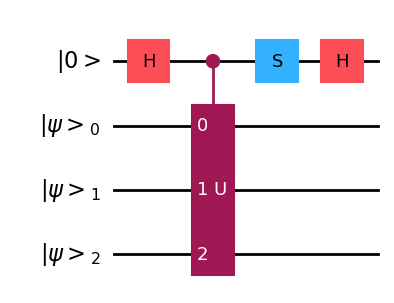

In [20]:
data_width = 1
ankira_width = 3



# 適当な状態|ψ>を作る回路
psi_circuit = QuantumCircuit(ankira_width, name='U')
psi_circuit.ry(0.7, 2)
psi_circuit.cx(2, 1)
psi_circuit.rz(0.5, 1)
psi_circuit.cx(1, 0)
controlled_U_gate = psi_circuit.to_gate().control(1)
# パーツが全て揃ったので、内積を計算する回路を作る
reg_data1 = QuantumRegister(data_width, name='|0>')
reg_data2 = QuantumRegister(ankira_width, name='|ψ>')

circuit = QuantumCircuit(reg_data1, reg_data2, name='Hadamard_test')
# 他の回路や別に定義したゲートを回路オブジェクトに組み込むときはappend()メソッドを使う
# qargsでもとの回路の量子ビットを組み込み先のどの量子ビットに対応させるかを指定する
circuit.h(reg_data1)
circuit.append(controlled_U_gate, qargs=list(reg_data1) + list(reg_data2))
circuit.s(reg_data1)
circuit.h(reg_data1)

circuit.draw(
    'mpl',
    style={'show_gate_label_qargs': False}
)